# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [6]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [7]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_10584/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_10584/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


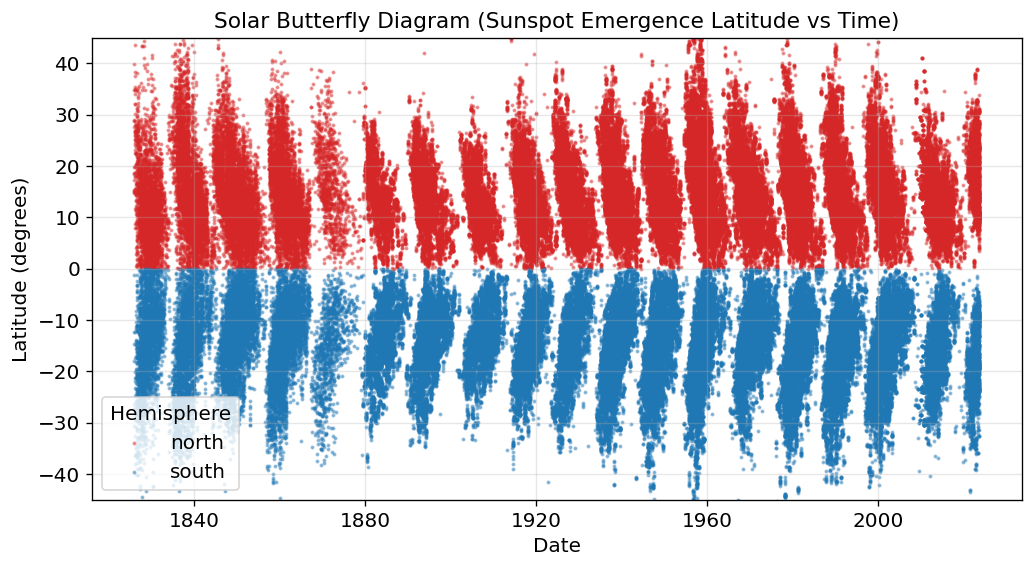

In [8]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:purple", "south": "tab:pink"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


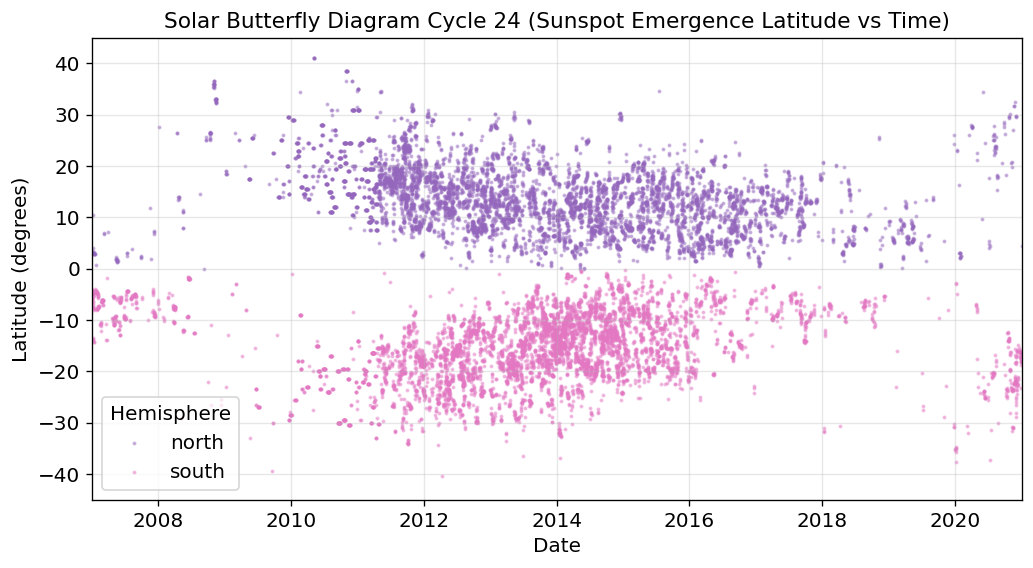

In [25]:
# Your code here: Visualize a single solar cycle
import matplotlib.pyplot as plt
from datetime import datetime

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:purple", "south": "tab:pink"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram Cycle 24 (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.set_xlim(datetime(2007, 1, 1), datetime(2021, 1, 1))
plt.show()





## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


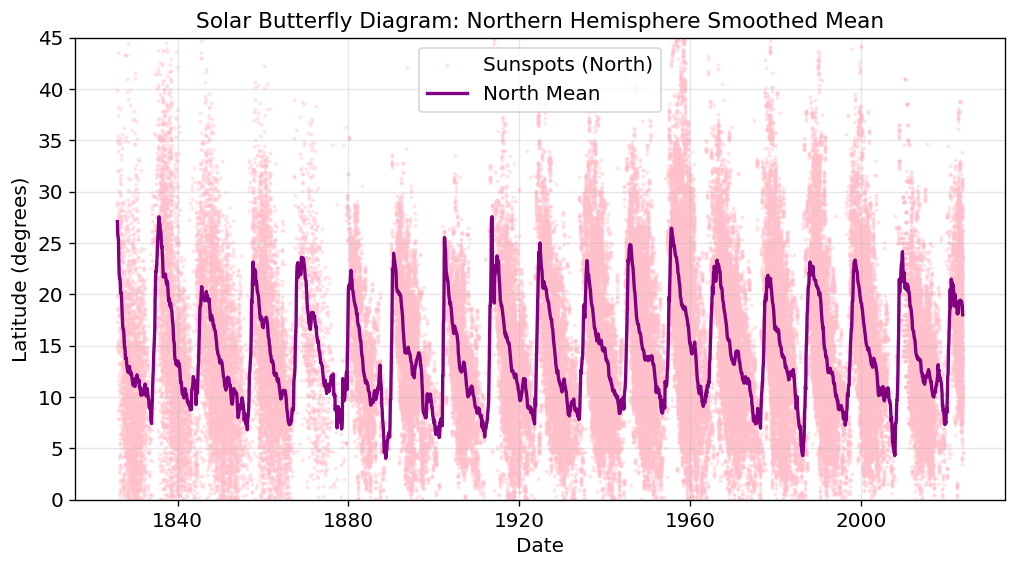

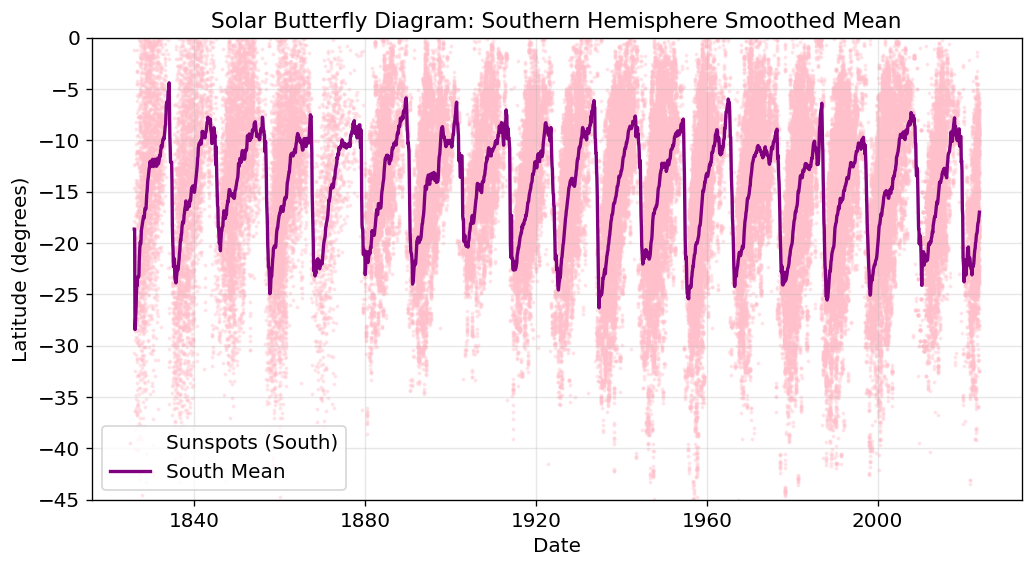

In [35]:
# Your code here: Calculate and plot mean latitudinal paths
import matplotlib.pyplot as plt
import pandas as pd

# Calculate monthly mean (using 'ME' as 'M')
monthly_mean = (df.groupby("hemisphere")["latitude"].resample("ME").mean().reset_index())

# Apply a 12-month rolling average to smooth the curve
monthly_mean["smoothed_latitude"] = monthly_mean.groupby("hemisphere")["latitude"].transform(lambda x: x.rolling(window=12, min_periods=1).mean())

# Plot separate figures for each hemisphere
for hemi in ["north", "south"]:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Filter raw data for the current hemisphere
    df_hemi = df[df["hemisphere"] == hemi]
    ax.scatter(df_hemi.index, df_hemi["latitude"], s=2, c="pink", alpha=0.3, label=f"Sunspots ({hemi.capitalize()})")

    # Plot the smoothed mean line
    subset = monthly_mean[monthly_mean["hemisphere"] == hemi]
    ax.plot(subset["date"], subset["smoothed_latitude"], color="purple", linewidth=2, label=f"{hemi.capitalize()} Mean")

    ax.set_title(f"Solar Butterfly Diagram: {hemi.capitalize()}ern Hemisphere Smoothed Mean")
    ax.set_xlabel("Date")
    ax.set_ylabel("Latitude (degrees)")

    # Set y-limits depending on the hemisphere to avoid empty space
    if hemi == "north":
        ax.set_ylim(0, 45)
    else:
        ax.set_ylim(-45, 0)

    ax.legend()
    plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*


**Chat's Response:**

Great question—and honestly, the difference between using AI and actually learning from it comes down almost entirely to how you prompt.

Since you’re tackling both machine learning and solar physics, you want prompts that force the AI to act like a teacher + research advisor + coding partner, not just a Wikipedia dump.

Here’s what works best:

⸻

🧠 1. Use “role + goal + constraints” prompting

Tell the AI how to teach you.

✅ Example

“Act like a graduate-level instructor in machine learning and heliophysics. Explain [topic] step-by-step, starting from intuition, then math, then application to solar data. Include a small coding example.”

This prevents shallow explanations and gives structure automatically.

⸻

🔬 2. Force layered explanations (this is HUGE)

Always ask for multiple levels:

✅ Template

“Explain this in 3 layers:
	1.	Intuition (no math)
	2.	Mathematical formulation
	3.	Application to solar physics (e.g., flare prediction, solar wind, or magnetograms)”

This mirrors how you actually learn in physics.

⸻

🧮 3. Tie ML concepts to physics immediately

Otherwise ML stays abstract and useless.

✅ Example

“Explain neural networks, then show how they could be used to predict solar flare activity from time-series data.”

Or even better:

“Compare this method to traditional physics-based modeling.”

⸻

💻 4. Always request active learning

Don’t just read—interact.

✅ Prompts
	•	“Give me a small problem to solve after explaining this.”
	•	“Quiz me with conceptual and math questions.”
	•	“Ask me what I think the next step is before revealing it.”

This turns passive reading into real learning.

⸻

📊 5. Use your actual data/work whenever possible

This is where AI becomes insanely powerful for you specifically.

✅ Example (based on your work)

“Here’s a light curve dataset I’m working with. Suggest a machine learning approach to detect flares and explain why it works physically.”

or

“I’m analyzing solar wind speed vs geomagnetic indices. What ML models would capture this relationship and why?”

⸻

🔁 6. Ask for comparisons (build intuition fast)

This is one of the fastest ways to level up.

✅ Example

“Compare random forests, neural networks, and Gaussian processes for modeling solar activity. Include pros/cons and when each fails.”

⸻

🧑‍🔬 7. Force research-style thinking

Since you’re already doing research, push the AI into that mode.

✅ Example

“If I wanted to publish a paper using ML on solar flare prediction, what approach would you recommend and why? What would reviewers criticize?”

⸻

⚠️ 8. Ask it to challenge you

Otherwise it will just agree with everything.

✅ Example

“Critique my approach and point out flaws.”
“What assumptions am I making that could break this model?”

⸻

🔧 9. Use iterative prompting (don’t settle for one answer)

Think of it like debugging your understanding.

Flow:
	1.	“Explain X”
	2.	“I don’t understand step 3—go deeper”
	3.	“Now derive it mathematically”
	4.	“Now show me code”
	5.	“Now apply it to solar data”

⸻

🧪 10. A “perfect prompt” for you specifically

If I had to give you one go-to:

🔥 Master Prompt

“Act as a research mentor in machine learning and solar physics. Teach me [topic] step-by-step:
	•	Start with intuition
	•	Then derive the math
	•	Then connect it to real solar physics applications (like flare prediction, solar wind, or magnetohydrodynamics)
	•	Then give a small Python example
	•	Then give me a problem to solve
	•	Then critique my understanding with questions”

⸻

🚀 Bonus: What to avoid
	•	❌ “Explain X” (too vague)
	•	❌ “Give me notes” (passive learning)
	•	❌ “Summarize this” (low retention)
	•	❌ Copy-paste coding without understanding

⸻

If you want to go next-level

I can:
	•	Build you a structured ML-for-solar-physics learning roadmap
	•	Help you apply ML directly to your flare/light curve research
	•	Or walk you through a real mini project step-by-step

Just tell me 👍

How will you apply this advice in future notebooks?

*   I have been using AI for a long time now, and I think that I have found out what works best for me in my usages.
*   When I ask questions, I am usually specific about what I want. Also, I ask Chat to go deeper into topics that I am unfamiliar with so I can learn them. I double check code, and I only use it when I have a question about a topic or I genuinely don't know what is going on in class.

